# 1. Imports

In [123]:
import sys
import re
import datetime as dt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append('../utils')
from myutils import display_report, plot_categorical_dual, plot_numeric_report

print("Libraries loaded.")

Библиотеки загружены.


# 2. Loading data

In [124]:
# IMPORTANT: Id and Contact Name are loaded as strings (dtype=str).
# These are large identifier values (19-20 significant digits),
# which lose precision when read as float and can create
# thousands of false duplicates due to rounding.

RAW_PATH   = "../data/raw/Deals (Done).xlsx"
CLEAN_PATH = "../data/clean/deals_clean.pkl"

df = pd.read_excel(RAW_PATH, dtype={"Id": str, "Contact Name": str})

print(f"Size (raw file): {df.shape}")
print()
print(f"Columns: {list(df.columns)}")
df.head()

Размер (сырой файл): (21593, 23)

Столбцы: ['Id', 'Deal Owner Name', 'Closing Date', 'Quality', 'Stage', 'Lost Reason', 'Page', 'Campaign', 'SLA', 'Content', 'Term', 'Source', 'Payment Type', 'Product', 'Education Type', 'Created Time', 'Course duration', 'Months of study', 'Initial Amount Paid', 'Offer Total Amount', 'Contact Name', 'City', 'Level of Deutsch']


,Id,Deal Owner Name,Closing Date,Quality,Stage,Lost Reason,Page,Campaign,SLA,Content,...,Product,Education Type,Created Time,Course duration,Months of study,Initial Amount Paid,Offer Total Amount,Contact Name,City,Level of Deutsch
0,5805028000056864695,Ben Hall,NaN,NaN,New Lead,NaN,/eng/test,03.07.23women,NaN,v16,...,NaN,NaN,21.06.2024 15:30,NaN,NaN,NaN,NaN,5805028000056849495,NaN,NaN
1,5805028000056859489,Ulysses Adams,NaN,NaN,New Lead,NaN,/at-eng,NaN,NaN,NaN,...,Web Developer,Morning,21.06.2024 15:23,6.0,NaN,0,2000,5805028000056834471,NaN,NaN
2,5805028000056832357,Ulysses Adams,21.06.2024,D - Non Target,Lost,Non target,/at-eng,engwien_AT,00:26:43,b1-at,...,NaN,NaN,21.06.2024 14:45,NaN,NaN,NaN,NaN,5805028000056854421,NaN,NaN
3,5805028000056824246,Eva Kent,21.06.2024,E - Non Qualified,Lost,Invalid number,/eng,04.07.23recentlymoved_DE,01:00:04,bloggersvideo14com,...,NaN,NaN,21.06.2024 13:32,NaN,NaN,NaN,NaN,5805028000056889351,NaN,NaN
4,5805028000056873292,Ben Hall,21.06.2024,D - Non Target,Lost,Non target,/eng,discovery_DE,00:53:12,website,...,NaN,NaN,21.06.2024 13:21,NaN,NaN,NaN,NaN,5805028000056876176,NaN,NaN


# 3. Removing fully empty rows

In [125]:
# Excel exports often contain technical empty rows
# at the end of the file. Check and remove them before
# any further data processing.

fully_empty = df.isna().all(axis=1)
print(f"Fully empty rows: {fully_empty.sum()}")

Полностью пустых строк: 0


In [126]:
df = df[~fully_empty].reset_index(drop=True)

print(f"Size after removing empty rows: {df.shape}")

Размер после удаления пустых строк: (21593, 23)


In [127]:
# Rows without Id are removed because without a deal identifier
# the record cannot be used for analysis

no_id = df["Id"].isna()
print(f"Rows without Id: {no_id.sum()}")

Строк без Id: 0


In [128]:
df = df[~no_id].reset_index(drop=True)

print(f"Size after removing rows without Id: {df.shape}")

Размер после: (21593, 23)


# 4. Initial data overview

In [129]:
display_report(df, df_name="Deals (raw)")

  ОТЧЁТ: Deals (raw)
  Размер : 21,593 строк × 23 столбцов
  Память : 9.31 MB

  Пропуски (NaN):
    Deal Owner Name                              29 (0.1%)
    Closing Date                               6948 (32.2%)
    Quality                                    2253 (10.4%)
    Lost Reason                                5469 (25.3%)
    Campaign                                   5526 (25.6%)
    SLA                                        6060 (28.1%)
    Content                                    7446 (34.5%)
    Term                                       9139 (42.3%)
    Payment Type                              21097 (97.7%)
    Product                                   18001 (83.4%)
    Education Type                            18294 (84.7%)
    Course duration                           18006 (83.4%)
    Months of study                           20753 (96.1%)
    Initial Amount Paid                       17428 (80.7%)
    Offer Total Amount                        17408 (80.6%)
    

In [130]:
# 1. Deal Owner Name
# The manager is not assigned in rare cases (0.1%).
# Fill with "Unknown" instead of removing, because the deal is still valid.

df["Deal Owner Name"] = df["Deal Owner Name"].fillna("Unknown")
print(f"Deal Owner Name nulls: {df['Deal Owner Name'].isna().sum()}")

Deal Owner Name nulls: 0


In [131]:
# 2. Contact Name
# The contact is not linked in rare cases.
# Fill with "Unknown", because the deal may still be valid.

df["Contact Name"] = df["Contact Name"].fillna("Unknown")
print(f"Contact Name nulls: {df['Contact Name'].isna().sum()}")

Contact Name nulls: 0


In [132]:
# Business logic:
# Lost Reason is filled by the manager ONLY when a deal
# is moved to the Lost stage. For all other stages
# (Payment Done, Call Delayed, Waiting For Payment, etc.)
# this field is empty and this is expected, not a data issue.

# What we do:
# 1. Check the real distribution before changes
# 2. Validate the logic: do all Lost deals have a reason?
# 3. NaN for non-Lost deals -> "Not Lost"
# 4. NaN for Lost deals -> "Not Specified" (manager did not provide a reason)

# Step 1: check current distribution before normalization
print("Lost Reason distribution BEFORE normalization:")
print(df["Lost Reason"].value_counts(dropna=False))
print(f"\nTotal NaN in Lost Reason: {df['Lost Reason'].isna().sum():,}")

Lost Reason, распределение ДО нормализации:
Lost Reason
NaN                                        5469
Doesn't Answer                             4135
Changed Decision                           2146
Duplicate                                  1771
Non target                                 1761
Stopped Answering                          1588
Invalid number                             1481
needs time to think                         655
Expensive                                   626
Conditions are not suitable                 531
Next stream                                 288
Inadequate                                  176
Gutstein refusal                            172
Considering a different direction in IT     148
Not for myself                              145
Does not speak English                      138
Didn't leave an application                 133
Thought for free                            110
Does not know how to use a computer          50
Went to Rivals                  

In [133]:
# Step 2: validate logic by stages
# Check whether Lost deals have reasons or also contain NaN values.

lost_mask = df["Stage"] == "13_Lost"
not_lost_mask = df["Stage"] != "13_Lost"

lost_with_reason    = (lost_mask & df["Lost Reason"].notna()).sum()
lost_without_reason = (lost_mask & df["Lost Reason"].isna()).sum()
not_lost_with_nan   = (not_lost_mask & df["Lost Reason"].isna()).sum()
not_lost_with_value = (not_lost_mask & df["Lost Reason"].notna()).sum()

print("\nLogic validation")
print(f"Stage = Lost + reason filled: {lost_with_reason:,}")
print(f"Stage = Lost + reason missing: {lost_without_reason:,}")
print(f"Stage != Lost + NaN (expected): {not_lost_with_nan:,}")
print(f"Stage != Lost + reason filled: {not_lost_with_value:,}")


Проверка логики
Stage = Lost + причина заполнена: 0
Stage = Lost + причина НЕ заполнена: 0
Stage != Lost + NaN (норма) : 5,469
Stage != Lost + причина заполнена : 16,124


In [134]:
# Step 3: NaN for NON-Lost deals -> "Not Lost"
# This is the main source of missing values; the deal was simply not lost.
df.loc[not_lost_mask & df["Lost Reason"].isna(), "Lost Reason"] = "Not Lost"

# Step 4: NaN for Lost deals -> "Not Specified"
# The manager forgot to provide a reason when moving the deal to Lost.
# Do not remove these rows: the deal is valid, only the comment is missing.
df.loc[lost_mask & df["Lost Reason"].isna(), "Lost Reason"] = "Not Specified"

# Step 5: final validation
print("\nLost Reason distribution AFTER normalization:")
print(df["Lost Reason"].value_counts(dropna=False))

print(f"\nRemaining NaN: {df['Lost Reason'].isna().sum()}")


Lost Reason, распределение ПОСЛЕ нормализации:
Lost Reason
Not Lost                                   5469
Doesn't Answer                             4135
Changed Decision                           2146
Duplicate                                  1771
Non target                                 1761
Stopped Answering                          1588
Invalid number                             1481
needs time to think                         655
Expensive                                   626
Conditions are not suitable                 531
Next stream                                 288
Inadequate                                  176
Gutstein refusal                            172
Considering a different direction in IT     148
Not for myself                              145
Does not speak English                      138
Didn't leave an application                 133
Thought for free                            110
Does not know how to use a computer          50
Went to Rivals              

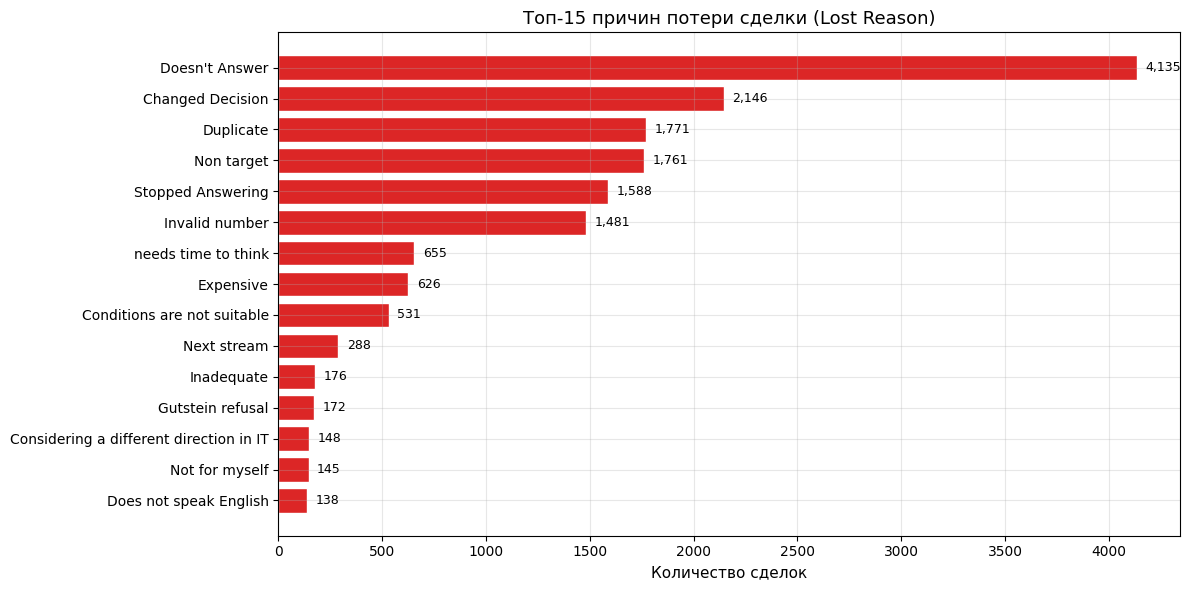

In [135]:
# Step 6: visualization for analysis
# Analyze only real lost reasons (exclude "Not Lost")

lost_reasons = (
    df[df["Lost Reason"] != "Not Lost"]["Lost Reason"]
    .value_counts()
    .head(15)
)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(
    lost_reasons.index[::-1],
    lost_reasons.values[::-1],
    color="#DC2626", edgecolor="white"
)

ax.set_title("Top-15 deal loss reasons (Lost Reason)", fontsize=13)
ax.set_xlabel("Number of deals")

for i, (bar, val) in enumerate(zip(ax.patches, lost_reasons.values[::-1])):
    ax.text(
        bar.get_width() + max(lost_reasons.values) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{val:,}",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [136]:
# Step 7: summary
total_lost = lost_mask.sum()

print(f"\nTotal Lost deals: {total_lost:,}")
print(f"Reason provided: {lost_with_reason:,} "
      f"({lost_with_reason/total_lost*100:.1f}%)")
print(f"Reason missing: {lost_without_reason:,} "
      f"({lost_without_reason/total_lost*100:.1f}%)")

print(f"\nConclusion: managers fill in Lost Reason in "
      f"{lost_with_reason/total_lost*100:.1f}% of cases")


Всего Lost сделок: 0
Из них — причина указана: 0 (nan%)
Из них — причина НЕ указана: 0 (nan%)

Вывод: менеджеры заполняют Lost Reason в nan% случаев


In [137]:
# 4. Campaign
# No campaign means the lead did not come from paid advertising
# (organic traffic, direct visit, referral).
# Fill with an explicit label instead of removing the data.

df["Campaign"] = df["Campaign"].fillna("not set")
print(f"Campaign nulls: {df['Campaign'].isna().sum()}")

Campaign nulls: 0


In [138]:
# 5. Content
# Content = specific advertisement (Ad).
# Missing value means there was no advertising content (organic traffic).

df["Content"] = df["Content"].fillna("not set")
print(f"Content nulls: {df['Content'].isna().sum()}")

Content nulls: 0


In [139]:
# 6. Term
# Term = AdGroup. Similar to Content, missing value means
# there was no advertising group (organic traffic).

df["Term"] = df["Term"].fillna("not set")
print(f"Term nulls: {df['Term'].isna().sum()}")

Term nulls: 0


In [140]:
df['Payment Type'].value_counts()

Payment Type
Recurring Payments    350
One Payment           141
Reservation             5
Name: count, dtype: int64

In [158]:
# Payment Type
# Logic:
# 1. Stage = Payment Done + Initial == Offer Total -> One Payment
#    (the customer paid the full amount immediately)
# 2. Stage = Payment Done + Initial < Offer Total -> Recurring Payments
#    (the customer paid partially -> installment plan)
# 3. All other cases -> No Payment
#    (the deal is not paid, payment type is not applicable)

print("Payment Type — BEFORE:")
print(df["Payment Type"].value_counts(dropna=False))

# Masks for conditions
mask_paid = df["Stage"] == "12_Payment_Done"

mask_one_payment = (
    mask_paid
    & df["Initial Amount Paid"].notna()
    & df["Offer Total Amount"].notna()
    & (df["Initial Amount Paid"] == df["Offer Total Amount"])
)

mask_recurring = (
    mask_paid
    & df["Initial Amount Paid"].notna()
    & df["Offer Total Amount"].notna()
    & (df["Initial Amount Paid"] < df["Offer Total Amount"])
)

# Fill only missing values (keep already existing values unchanged)
df.loc[mask_one_payment & df["Payment Type"].isna(), "Payment Type"] = "One Payment"
df.loc[mask_recurring & df["Payment Type"].isna(), "Payment Type"] = "Recurring Payments"

# Remaining NaN -> No Payment
df["Payment Type"] = df["Payment Type"].fillna("No Payment")

print("\nPayment Type — AFTER:")
print(df["Payment Type"].value_counts(dropna=False))

print(f"\nRemaining NaN: {df['Payment Type'].isna().sum()}")

Payment Type — ДО:
Payment Type
NaN                   21097
Recurring Payments      350
One Payment             141
Reservation               5
Name: count, dtype: int64

Payment Type — ПОСЛЕ:
Payment Type
No Payment            20618
Recurring Payments      818
One Payment             152
Reservation               5
Name: count, dtype: int64

Оставшихся NaN: 0


In [159]:
# 8. Product
# Logic:
# - If Stage = Payment Done + Initial Amount Paid is filled
#   -> the student is real, but the manager did not specify the product
#   -> fill with "Not Specified" (data exists, product is unknown)
# - For all other cases (not paid)
#   -> this is not our student
#   -> fill with "Not Our Student"

print("\nProduct — BEFORE:")
print(df["Product"].value_counts(dropna=False))

mask_real_student = (
    mask_paid
    & df["Initial Amount Paid"].notna()
    & df["Product"].isna()
)

mask_not_student = (
    ~mask_paid
    & df["Product"].isna()
)

# Real student but product is missing
df.loc[mask_real_student, "Product"] = "Not Specified"

# Not our student
df.loc[mask_not_student, "Product"] = "Not Our Student"

# Safety check: fill remaining NaN (paid deals without payment amount)
df["Product"] = df["Product"].fillna("Not Specified")

print("\nProduct — AFTER:")
print(df["Product"].value_counts(dropna=False))

print(f"\nRemaining NaN: {df['Product'].isna().sum()}")


Product — ДО:
Product
Not Our Student        18001
Digital Marketing       1990
UX/UI Design            1022
Web Developer            575
Find yourself in IT        4
Data Analytics             1
Name: count, dtype: int64

Product — ПОСЛЕ:
Product
Not Our Student        18001
Digital Marketing       1990
UX/UI Design            1022
Web Developer            575
Find yourself in IT        4
Data Analytics             1
Name: count, dtype: int64

Оставшихся NaN: 0


In [143]:
# Logic control check
print("\nPayment Type validation by stages")
print(pd.crosstab(df["Stage"], df["Payment Type"]))


Проверка Payment Type по стадиям
Payment Type           One Payment  Recurring Payments  Reservation
Stage                                                              
Call Delayed                     2                   9            0
Lost                            21                  87            4
Payment Done                   113                 250            1
Qualificated                     3                   2            0
Registered on Webinar            0                   1            0
Waiting For Payment              2                   1            0


In [144]:
# Final validation
print("\n MISSING VALUES AFTER PROCESSING")

nulls = df.isna().sum()
nulls = nulls[nulls > 0]

if len(nulls) > 0:
    for col, cnt in nulls.items():
        print(f"  {col:<30} {cnt:>6} ({cnt/len(df)*100:.1f}%)")
else:
    print("No critical unprocessed missing values.")


 ПРОПУСКИ ПОСЛЕ ОБРАБОТКИ
  Closing Date                     6948 (32.2%)
  Quality                          2253 (10.4%)
  SLA                              6060 (28.1%)
  Payment Type                    21097 (97.7%)
  Education Type                  18294 (84.7%)
  Course duration                 18006 (83.4%)
  Months of study                 20753 (96.1%)
  Initial Amount Paid             17428 (80.7%)
  Offer Total Amount              17408 (80.6%)
  City                            19082 (88.4%)
  Level of Deutsch                20342 (94.2%)


In [ ]:
# SLA missing value means the manager did NOT contact the lead,
# or the call was not recorded in CRM.
# This is important analytical information, so we do NOT fill it.
# Keep NaN as a separate category during SLA analysis.
# (Already handled during sla_to_minutes conversion)

In [ ]:
# Initial Amount Paid / Offer Total Amount
# Missing amounts mean that no payment was made.
# Keep NaN values because revenue analysis uses only is_paid = True,
# where payment amounts are available.
# Do not replace with zero, as zero values would distort
# mean and median calculations in describe().

In [ ]:
# Closing Date
# Missing closing date means the deal has not been closed yet
# or the manager has not recorded the closing information.
# Keep NaN values because this is a valid absence of data, not an error.

# 5. Checking Id uniqueness after precision correction

In [145]:
dup_id = df["Id"].duplicated().sum()
print(f"Duplicate Ids (after reading as string): {dup_id}")

if dup_id > 0:
    print("\nExamples of duplicated Ids:")
    print(df[df["Id"].duplicated(keep=False)].sort_values("Id").head(10)
          [["Id", "Deal Owner Name", "Created Time", "Stage"]])

Дублирующихся Id (после чтения как строка): 0


# 6. Date conversion

In [146]:
# Created Time format: "21.06.2024 15:30" (day.month.year hour:minute)
# Closing Date format: "21.06.2024"       (date only, without time)
#
# Specify the format explicitly (format=) because it is faster and more reliable
# than automatic detection and prevents errors caused by ambiguity
# (day/month order confusion).

df["Created Time"] = pd.to_datetime(df["Created Time"], format="%d.%m.%Y %H:%M", errors="coerce")

df["Closing Date"] = pd.to_datetime(df["Closing Date"], format="%d.%m.%Y", errors="coerce")

print("Date types:")
print(df[["Created Time", "Closing Date"]].dtypes)

print(f"\nUnrecognized Created Time : {df['Created Time'].isna().sum()}")
print(f"Unrecognized Closing Date : {df['Closing Date'].isna().sum()}")

print(f"\nCreation range: {df['Created Time'].min()} — {df['Created Time'].max()}")

Типы дат:
Created Time    datetime64[us]
Closing Date    datetime64[us]
dtype: object

Не распознано Created Time : 0
Не распознано Closing Date : 6948

Диапазон создания: 2023-07-03 17:03:00 — 2024-06-21 15:30:00


# 7. SLA processing (manager response time)

In [147]:
# IMPORTANT DIFFERENCE from the template: in this file SLA is already a READY
# duration value (manager response time), NOT a date/time point.
# Therefore, it is NOT necessary to subtract Created Time from SLA.

# Technical Excel detail: when exporting, duration fields
# are stored as datetime.time for values < 24 hours,
# and as datetime.timedelta for values >= 24 hours.
# Therefore, a universal conversion function is needed
# to convert both types into a single unit of measurement: minutes.

# The result is stored in a NEW column "SLA Minutes"; the original
# "SLA" column remains unchanged.

def sla_to_minutes(value):
    """Converts SLA (time or timedelta) into minutes (float)."""
    if pd.isna(value):
        return np.nan
    if isinstance(value, dt.time):
        return value.hour * 60 + value.minute + value.second / 60
    if isinstance(value, dt.timedelta):
        return value.total_seconds() / 60
    return np.nan

df["SLA Minutes"] = df["SLA"].apply(sla_to_minutes)

print("SLA (manager response time, minutes):")
print(df["SLA Minutes"].describe())

SLA (время ответа менеджера, минуты):
count     15533.000000
mean       1930.437056
std       12287.543927
min           0.050000
25%          73.000000
50%         331.566667
75%         938.633333
max      448474.400000
Name: SLA Minutes, dtype: float64


# 8. Deal stage normalization (Stage)

In [148]:
# Real stages in this dataset (full list from the data):
# Lost, Call Delayed, Registered on Webinar, Payment Done,
# Waiting For Payment, Qualificated, Registered on Offline Day,
# Need to Call - Sales, Need To Call, Test Sent,
# Need a consultation, New Lead, Free Education

# The original "Stage" column is normalized in place (converted
# to a consistent format), and the binary flag is stored in a new column
# "Is Paid".

print("Unique stages (before normalization):")
print(df["Stage"].value_counts(dropna=False))

df["Stage"] = df["Stage"].astype(str).str.strip()

# Numeric prefix reflects the approximate sequence
# of lead movement through the funnel — required for logical sorting
# in charts (CRM did not provide unified stage numbering)

STAGE_ORDER = {
    "New Lead":                     "01_New_Lead",
    "Need a consultation":           "02_Need_Consultation",
    "Need To Call":                  "03_Need_To_Call",
    "Need to Call - Sales":          "03_Need_To_Call_Sales",
    "Qualificated":                  "04_Qualificated",
    "Call Delayed":                  "05_Call_Delayed",
    "Test Sent":                     "06_Test_Sent",
    "Registered on Webinar":         "07_Registered_Webinar",
    "Registered on Offline Day":     "07_Registered_Offline_Day",
    "Waiting For Payment":           "09_Waiting_For_Payment",
    "Payment Done":                  "12_Payment_Done",
    "Free Education":                "12_Free_Education",
    "Lost":                          "13_Lost",
    "nan":                           "00_Unknown",
}

df["Stage"] = df["Stage"].map(lambda x: STAGE_ORDER.get(x, f"99_{x}"))

# Binary flag: whether the deal was paid
# Free Education is NOT considered paid because it does not generate revenue
df["Is Paid"] = df["Stage"] == "12_Payment_Done"

print("\nStages after normalization:")
print(df["Stage"].value_counts())

print(f"\nPaid deals: {df['Is Paid'].sum():,}")

Уникальные стадии (до нормализации):
Stage
Lost                         15743
Call Delayed                  2248
Registered on Webinar         2072
Payment Done                   858
Waiting For Payment            325
Qualificated                   128
Registered on Offline Day      100
Need to Call - Sales            33
Need To Call                    31
Test Sent                       25
Need a consultation             23
New Lead                         6
Free Education                   1
Name: count, dtype: int64

Стадии после нормализации:
Stage
13_Lost                      15743
05_Call_Delayed               2248
07_Registered_Webinar         2072
12_Payment_Done                858
09_Waiting_For_Payment         325
04_Qualificated                128
07_Registered_Offline_Day      100
03_Need_To_Call_Sales           33
03_Need_To_Call                 31
06_Test_Sent                    25
02_Need_Consultation            23
01_New_Lead                      6
12_Free_Education     

# 9. Lead quality normalization (Quality)

In [149]:
# Real scale in the data:
# A - High, B - Medium, C - Low, D - Non Target, E - Non Qualified
# "F" and NaN
#
# The original "Quality" column is normalized in place,
# and the numerical rating is stored in a new column "Quality Score".

print("Lead quality (before):")
print(df["Quality"].value_counts(dropna=False))

df["Quality"] = df["Quality"].astype(str).str.strip()

QUALITY_MAP = {
    "A - High":          "A",
    "B - Medium":        "B",
    "C - Low":           "C",
    "D - Non Target":    "D",
    "E - Non Qualified": "E",
    "F":                 "F",
    "nan":               "Unknown", # missing value -> not defined
}

# Everything not found in the dictionary -> "Unknown"
df["Quality"] = df["Quality"].map(lambda x: QUALITY_MAP.get(x, "Unknown"))

# Numerical rating: A=6 (hot lead), F=1 (lower than non-qualified)
# Unknown = 0, separately, to avoid confusion with real ratings
quality_score_map = {
    "A": 6,
    "B": 5,
    "C": 4,
    "D": 3,
    "E": 2,
    "F": 1,
    "Unknown": 0,   # required to avoid astype("int8") conversion error
}

df["Quality Score"] = df["Quality"].map(quality_score_map).astype("int8")

print("\nQuality after normalization:")
print(df["Quality"].value_counts(dropna=False))

print("\nQuality Score distribution:")
print(df["Quality Score"].value_counts().sort_index())

Качество лидов (до):
Quality
E - Non Qualified    7634
D - Non Target       6248
C - Low              3459
NaN                  2253
B - Medium           1564
A - High              432
F                       3
Name: count, dtype: int64

Качество после нормализации:
Quality
E          7634
D          6248
C          3459
Unknown    2253
B          1564
A           432
F             3
Name: count, dtype: int64

Quality Score распределение:
Quality Score
0    2253
1       3
2    7634
3    6248
4    3459
5    1564
6     432
Name: count, dtype: int64


# 10. Date anomalies: Closing Date < Created Time

In [150]:
# According to business logic (customer FAQ): if the closing date is earlier
# than the creation date, it is a data error.

invalid_dates = (
    df["Closing Date"].notna()
    & df["Created Time"].notna()
    & (df["Closing Date"] < df["Created Time"])
)

print(f"Rows with Closing Date < Created Time: {invalid_dates.sum()}")

# Unpaid deals: remove incorrect closing date
df.loc[invalid_dates & ~df["Is Paid"], "Closing Date"] = pd.NaT

# Paid deals: closing date corresponds to the payment date,
# therefore, in case of an error, use the creation date as the closest
# reliable reference point
df.loc[invalid_dates & df["Is Paid"], "Closing Date"] = \
    df.loc[invalid_dates & df["Is Paid"], "Created Time"]

remaining = (
    df["Closing Date"].notna()
    & df["Created Time"].notna()
    & (df["Closing Date"] < df["Created Time"])
).sum()

print(f"Anomalies after correction: {remaining}")

Строк с Closing Date < Created Time: 3312
Аномалий после исправления: 0


# 11. Payment amount normalization (German currency format)

In [151]:
# Original columns "Initial Amount Paid" and "Offer Total Amount"
# are converted to float directly in place (column names remain unchanged).

# After checking the actual file, it was found:
# Most values are stored as integers (numbers)
# Only 3 string values exist, all in € format:
# Initial Amount Paid : "€ 3.500,00"
# Offer Total Amount  : "€ 2.900,00", "€ 11398,00"
#
# The $ sign visible in Excel is only visual cell formatting
# (display format). The actual data is stored as numbers without currency symbols.
# Python/Pandas reads them correctly as integers, so no separate processing is required.

def parse_amount(value):
    """
    Converts payment amount value into float.
    Handles:
      - numbers (int, float), directly converted to float
      - strings like '€ 3.500,00', removes € and converts
        German format (dot = thousands separator, comma = decimal separator)
        into standard float format
    """
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float)):
        return float(value)

    # String format with €
    text = str(value).replace("€", "").strip()

    # "3.500,00" -> "3500.00"
    text = text.replace(".", "").replace(",", ".")

    try:
        return float(text)
    except ValueError:
        return np.nan

df["Initial Amount Paid"] = df["Initial Amount Paid"].apply(parse_amount)
df["Offer Total Amount"] = df["Offer Total Amount"].apply(parse_amount)

print("Initial Amount Paid (after parsing):")
print(df["Initial Amount Paid"].describe())

print("\nOffer Total Amount (after parsing):")
print(df["Offer Total Amount"].describe())

# Validation check: no string values should remain
assert df["Initial Amount Paid"].apply(lambda x: isinstance(x, str)).sum() == 0
assert df["Offer Total Amount"].apply(lambda x: isinstance(x, str)).sum() == 0

print("\nValidation passed — all values are numeric.")

Initial Amount Paid (после парсинга):
count     4165.000000
mean       950.086915
std       1422.152577
min          0.000000
25%        300.000000
50%       1000.000000
75%       1000.000000
max      11500.000000
Name: Initial Amount Paid, dtype: float64

Offer Total Amount (после парсинга):
count     4185.000000
mean      7128.724253
std       4636.020784
min          0.000000
25%       3000.000000
50%      11000.000000
75%      11000.000000
max      11500.000000
Name: Offer Total Amount, dtype: float64

Проверка пройдена — все значения числовые.


# 12. Payment amounts business logic

In [152]:
# Rules from customer FAQ:
# 1) Months of study = NaN:
#    - If Stage = Payment Done -> replace NaN with 0
#    - If Stage != Payment Done -> replace NaN with -1
# 2) Initial Amount Paid cannot exceed Offer Total Amount ->
#    if it does, swap values only in these rows
#    (logic: the manager most likely mixed up the columns during data entry)
# 3) Values 0, 1, 9 are symbolic demo accesses, keep them unchanged

print(f"Missing Months of study (before): {df['Months of study'].isna().sum():,}")

# Mask: paid deals
mask_paid = df["Stage"] == "12_Payment_Done"
mask_not_paid = ~mask_paid

# Step 1a: paid but months are missing -> 0
df.loc[mask_paid & df["Months of study"].isna(), "Months of study"] = 0

# Step 1b: not paid and months are missing -> -1
df.loc[mask_not_paid & df["Months of study"].isna(), "Months of study"] = -1

print(f"Missing Months of study (after): {df['Months of study'].isna().sum():,}")

print("\nMonths of study distribution:")
print(df["Months of study"].value_counts().sort_index())

# Step 2: Initial > Offer Total -> swap values only in these rows
# Logic: if initial amount is greater than total amount,
# the manager likely entered values in the wrong columns,
# therefore we swap them

mask_inv = (
    df["Initial Amount Paid"].notna()
    & df["Offer Total Amount"].notna()
    & (df["Initial Amount Paid"] > df["Offer Total Amount"])
)

print(f"\nRows where Initial > Offer Total (before swap): {mask_inv.sum()}")

# Save original initial amount temporarily
temp = df.loc[mask_inv, "Initial Amount Paid"].copy()

# Swap values only where Initial > Offer Total
df.loc[mask_inv, "Initial Amount Paid"] = df.loc[mask_inv, "Offer Total Amount"]
df.loc[mask_inv, "Offer Total Amount"] = temp

# Check: after swap there should be no such rows
mask_check = (
    df["Initial Amount Paid"].notna()
    & df["Offer Total Amount"].notna()
    & (df["Initial Amount Paid"] > df["Offer Total Amount"])
)

print(f"Rows where Initial > Offer Total (after swap): {mask_check.sum()}")

print("\nFinal amount statistics:")
print(df[["Initial Amount Paid", "Offer Total Amount", "Months of study"]].describe())

Пустых Months of study (до): 20,753
Пустых Months of study (после): 0

Распределение Months of study:
Months of study
-1.0     20735
 0.0        18
 1.0        68
 2.0       104
 3.0        94
 4.0        93
 5.0        64
 6.0       107
 7.0        79
 8.0        83
 9.0        61
 10.0       42
 11.0       45
Name: count, dtype: int64

Строк, где Initial > Offer Total (до swap): 58
Строк, где Initial > Offer Total (после swap): 0

Итоговая статистика сумм:
       Initial Amount Paid  Offer Total Amount  Months of study
count          4165.000000         4185.000000     21593.000000
mean            929.796639         7148.917563        -0.748483
std            1347.438755         4631.221731         1.372550
min               0.000000            0.000000        -1.000000
25%             300.000000         3000.000000        -1.000000
50%            1000.000000        11000.000000        -1.000000
75%            1000.000000        11000.000000        -1.000000
max           11000.00000

# 13. City normalization

In [153]:
# In the dataset, there are three types of "empty" city values:
#   1. Real NaN values (empty Excel cells)
#   2. "-"  — manager entered a dash instead of a city
#   3. ""   — empty string (blank) after trimming spaces
# All three have the same meaning: city is not specified.
# Combine them into one explicit category "Unknown".

print(f"Unique cities (before): {df['City'].nunique()}")
print(df["City"].value_counts(dropna=False).head(15))

# Step 1: remove spaces around city names
df["City"] = df["City"].str.strip()

# Step 2: empty strings "" -> NaN (to handle with fillna)
df["City"] = df["City"].replace({"": np.nan})

# Step 3: "-" -> NaN
df["City"] = df["City"].replace({"-": np.nan})

# Step 4: all NaN values (original + from steps 2 and 3) -> "Unknown"
df["City"] = df["City"].fillna("Unknown")

print(f"\nUnique cities (after): {df['City'].nunique()}")
print(df["City"].value_counts(dropna=False).head(15))

unknown_count = (df["City"] == "Unknown").sum()

print(f"\nRecords without city (Unknown): {unknown_count:,} "
      f"({unknown_count / len(df) * 100:.1f}%)")

Уникальных городов (до): 876
City
NaN           19082
-               348
Berlin          182
München          74
Hamburg          62
Nürnberg         45
Leipzig          45
Düsseldorf       33
Dresden          28
Frankfurt        27
Dortmund         26
Köln             25
Stuttgart        20
Duisburg         19
Hannover         19
Name: count, dtype: int64

Уникальных городов (после): 876
City
Unknown       19430
Berlin          182
München          74
Hamburg          62
Nürnberg         45
Leipzig          45
Düsseldorf       33
Dresden          28
Frankfurt        27
Dortmund         26
Köln             25
Stuttgart        20
Duisburg         19
Hannover         19
Bremen           17
Name: count, dtype: int64

Записей без города (Unknown): 19,430 (90.0%)


# 14. German language level normalization (Level of Deutsch)

In [154]:
# The logic fully matches the DAX measure "German Level Clean":
#   1. Convert to lowercase and remove spaces
#   2. Replace Cyrillic letters with visually identical Latin letters:
#      б -> b, в -> b, а -> a, с -> c
#   3. Search for substrings (not whole words), as in CONTAINSSTRING in DAX
#   4. Combine C1 and C2 into "C+" (as in DAX)
#   5. Everything undefined -> "Unknown" (as in DAX: ISBLANK / "Other")

# The order of checks is important: A1 before A2, B1 before B2,
# otherwise "a2" may match "a" first and return an incorrect result.

print(f"Unique values (before): {df['Level of Deutsch'].nunique()}")
print(df["Level of Deutsch"].value_counts(dropna=False).head(10))

def extract_deutsch_level(value):
    """
    Extracts German language level from free-text values.
    Logic is identical to the DAX measure 'German Level Clean':
    - Cyrillic -> Latin conversion (б -> b, в -> b, а -> a, с -> c)
    - substring search (CONTAINSSTRING), not word boundaries
    - C1/C2 → "C+"
    - everything else/empty -> "Unknown"
    """
    # Empty values and technical placeholders -> Unknown
    if pd.isna(value):
        return "Unknown"

    text = str(value).strip().lower()

    # Remove spaces inside the text (like SUBSTITUTE(...," ","") in DAX)
    text = text.replace(" ", "")

    # Technical placeholders -> Unknown
    if text in {"", "?", "-", ".", "0"}:
        return "Unknown"

    # German citizens, separate category
    if "гражд" in text or "citizen" in text or "гражданин" in text:
        return "Citizen"

    # Replace Cyrillic letters with Latin equivalents
    # Order is important: each character is replaced separately,
    # similar to DAX SUBSTITUTE
    text = (text
            .replace("б", "b")
            .replace("в", "b")
            .replace("а", "a")
            .replace("с", "c"))

    # CONTAINSSTRING logic, checking order as in DAX
    # A1 and A2 are checked before general "a", B1 before B2
    if "a1" in text:
        return "A1"
    if "a2" in text:
        return "A2"
    if "b1" in text:
        return "B1"
    if "b2" in text:
        return "B2"
    if "c1" in text:
        return "C+"
    if "c2" in text:
        return "C+"

    # Single "c" without number -> C+ (as in DAX: txt_clean = "c")
    if text == "c":
        return "C+"

    # Everything else -> "Other" in DAX,
    # but combined with Unknown because it is also undefined
    return "Unknown"


df["Level of Deutsch"] = df["Level of Deutsch"].apply(extract_deutsch_level)

# Set category order for correct sorting
# in visualizations (from lowest to highest)
DEUTSCH_ORDER = ["Unknown", "A1", "A2", "B1", "B2", "C+", "Citizen"]

df["Level of Deutsch"] = pd.Categorical(
    df["Level of Deutsch"],
    categories=DEUTSCH_ORDER,
    ordered=True
)

print(f"\nUnique values (after): {df['Level of Deutsch'].nunique()}")
print(df["Level of Deutsch"].value_counts(sort=False))

# Number of records with known German level
known = (df["Level of Deutsch"] != "Unknown").sum()

print(f"\nKnown level: {known:,} ({known/len(df)*100:.1f}%)")
print(f"Unknown: {(df['Level of Deutsch'] == 'Unknown').sum():,} "
      f"({(df['Level of Deutsch'] == 'Unknown').sum()/len(df)*100:.1f}%)")

Уникальных значений (до): 215
Level of Deutsch
NaN    20342
B1       219
б1       118
в1       100
b1        93
Б1        93
В1        63
А2        53
B2        45
а2        32
Name: count, dtype: int64

Уникальных значений (после): 7
Level of Deutsch
Unknown    20396
A1            28
A2           149
B1           815
B2           171
C+            30
Citizen        4
Name: count, dtype: int64

С известным уровнем : 1,197 (5.5%)
Unknown: 20,396 (94.5%)


# 15. Education Type: cleaning invalid value

In [155]:
# There are two types of "empty" values in the data:
#   1) "#REF!", a technical error, remove it
#   2) NaN (empty cells) -> "Unknown"

print("Education Type (before):")
print(df["Education Type"].value_counts(dropna=False))

# Step 1: "#REF!" and empty strings -> NaN
df["Education Type"] = df["Education Type"].replace({"#REF!": np.nan, "": np.nan})

# Step 2: all NaN values -> "Unknown"
df["Education Type"] = df["Education Type"].fillna("Unknown")

print("\nEducation Type (after):")
print(df["Education Type"].value_counts(dropna=False))

Education Type (до):
Education Type
NaN        18294
Morning     2895
Evening      404
Name: count, dtype: int64

Education Type (после):
Education Type
Unknown    18294
Morning     2895
Evening      404
Name: count, dtype: int64


# 16. Feature Engineering

In [156]:
# New features are added as additional columns,
# original data is not modified or lost.

# Deal duration from creation to closing, in days
df["Deal Duration Days"] = ((df["Closing Date"] - df["Created Time"]).dt.days)

df.loc[df["Deal Duration Days"] < 0, "Deal Duration Days"] = np.nan

# Creation and closing month for time series analysis
df["Created Month"] = df["Created Time"].dt.to_period("M")
df["Closing Month"] = df["Closing Date"].dt.to_period("M")

# Flag: whether the student is currently studying
# (or was studying at the moment of data export)
df["Is Studying"] = df["Months of study"].notna()

print("Features created.")

print(f"Studying (Is Studying): {df['Is Studying'].sum():,}")
print(f"Paid (Is Paid): {df['Is Paid'].sum():,}")

print("\nDeal Duration Days stats:")
print(df["Deal Duration Days"].describe())

Признаки созданы.
Учатся (Is Studying): 21,593
Оплатили (Is Paid): 858

Deal Duration Days stats:
count    11359.000000
mean        18.298794
std         34.560932
min          0.000000
25%          1.000000
50%          5.000000
75%         16.000000
max        334.000000
Name: Deal Duration Days, dtype: float64


# 17. Duplicate Removal

In [32]:
# The data shows that among the 1,771 rows marked as Duplicate, there are 2 rows with Stage = Payment Done.
# Removing them would result in the loss of actual revenue in the analysis.

# Additionally, in the CRM, "Duplicate" means that the same person submitted an inquiry twice, and the manager
# closed the second inquiry as a duplicate. However, this does not mean that the lead itself did not exist.
# It is simply information about the lead's behavior.

# The correct approach is to keep all rows and use Lost Reason = "Duplicate" as an analytical
# attribute (for example, to measure how many leads submit duplicate inquiries).

In [157]:
# Duplicates by Id — these are now true duplicate records
# (after fixing precision during the data loading stage),
# rather than artifacts caused by rounding.

dups_id = df.duplicated(subset=["Id"]).sum()
print(f"Duplicate records by Id: {dups_id}")
df = df.drop_duplicates(subset=["Id"]).reset_index(drop=True)

print(f"\nDataset shape after removing duplicates: {df.shape}")

Дублей по Id: 0

Размер после удаления дублей: (21593, 30)


# 18. Final Data Types

In [160]:
df["Id"] = df["Id"].astype("string")
df["Contact Name"] = df["Contact Name"].astype("string")
df["Deal Owner Name"] = df["Deal Owner Name"].astype("category")
df["Stage"] = df["Stage"].astype("category")
df["Quality"] = df["Quality"].astype("category")
df["Source"] = df["Source"].astype("category")
df["Campaign"] = df["Campaign"].astype("category")
df["Payment Type"] = df["Payment Type"].astype("category")
df["Product"] = df["Product"].astype("category")
df["Education Type"] = df["Education Type"].astype("category")
df["City"] = df["City"].astype("category")
df["Lost Reason"] = df["Lost Reason"].astype("category")
df["Page"] = df["Page"].astype("category")
df["Content"] = df["Content"].astype("category")
df["Term"] = df["Term"].astype("category")

df["Course duration"] = pd.to_numeric(df["Course duration"], errors="coerce").astype("Int8")
df["Months of study"] = pd.to_numeric(df["Months of study"], errors="coerce").astype("Int8")

print("Data types have been set.")
print(df.dtypes)

Типы установлены.
Id                             string
Deal Owner Name              category
Closing Date           datetime64[us]
Quality                      category
Stage                        category
Lost Reason                  category
Page                         category
Campaign                     category
SLA                            object
Content                      category
Term                         category
Source                       category
Payment Type                 category
Product                      category
Education Type               category
Created Time           datetime64[us]
Course duration                  Int8
Months of study                  Int8
Initial Amount Paid           float64
Offer Total Amount            float64
Contact Name                   string
City                         category
Level of Deutsch             category
SLA Minutes                   float64
Is Paid                          bool
Quality Score                   

# 19. Final Report on the Cleaned Dataset

In [161]:
display_report(df, df_name="Deals (clean)")

  ОТЧЁТ: Deals (clean)
  Размер : 21,593 строк × 30 столбцов
  Память : 3.87 MB

  Пропуски (NaN):
    Closing Date                              10234 (47.4%)
    SLA                                        6060 (28.1%)
    Course duration                           18006 (83.4%)
    Initial Amount Paid                       17428 (80.7%)
    Offer Total Amount                        17408 (80.6%)
    SLA Minutes                                6060 (28.1%)
    Deal Duration Days                        10234 (47.4%)
    Closing Month                             10234 (47.4%)

  КАТЕГОРИАЛЬНЫЕ столбцы:
          column    dtype  n_unique       top_value  top_freq  top_pct  null_count  null_pct
 Deal Owner Name category        28   Charlie Davis      2963    13.72           0      0.00
         Quality category         7               E      7634    35.35           0      0.00
           Stage category        13         13_Lost     15743    72.91           0      0.00
     Lost Reason categ

# 20. Key Visualizations

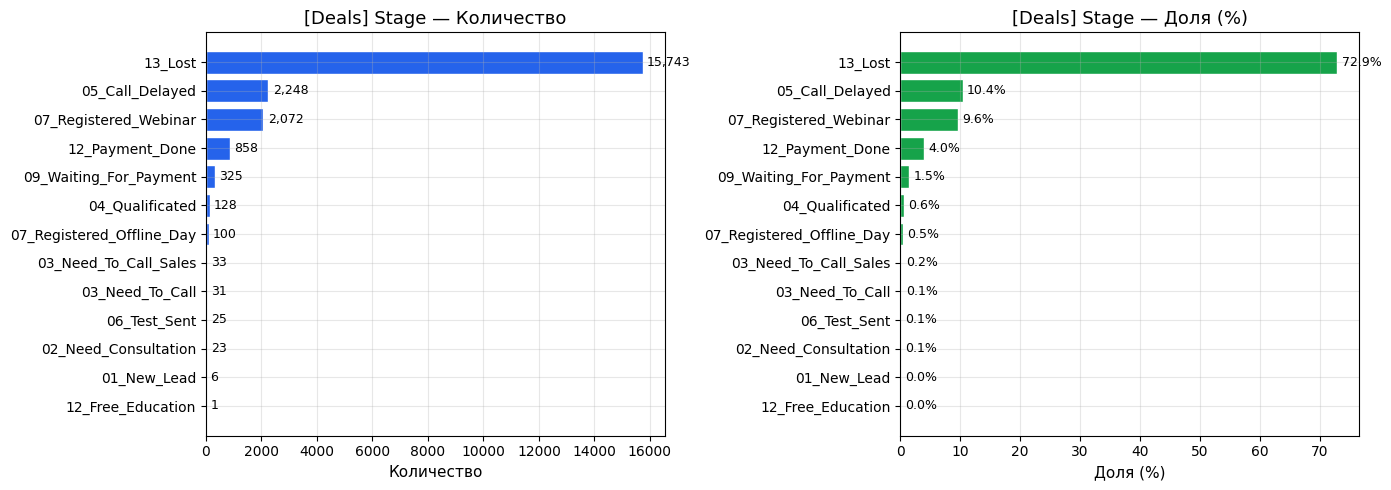

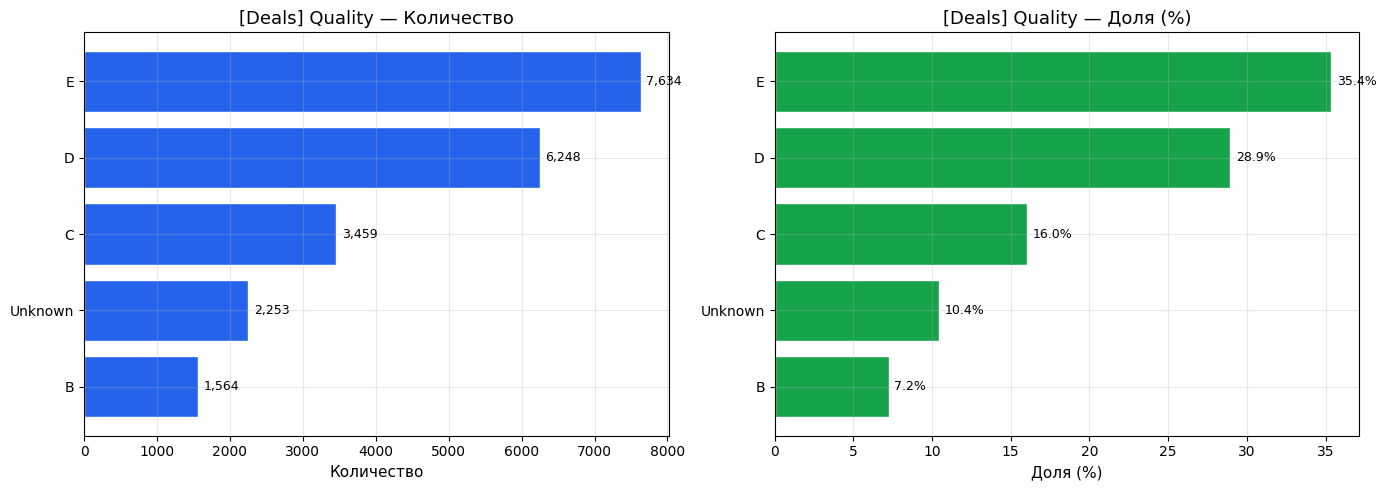

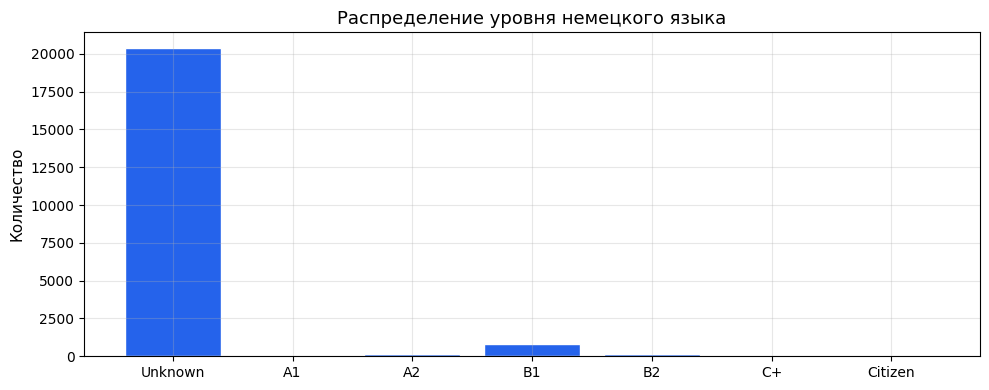

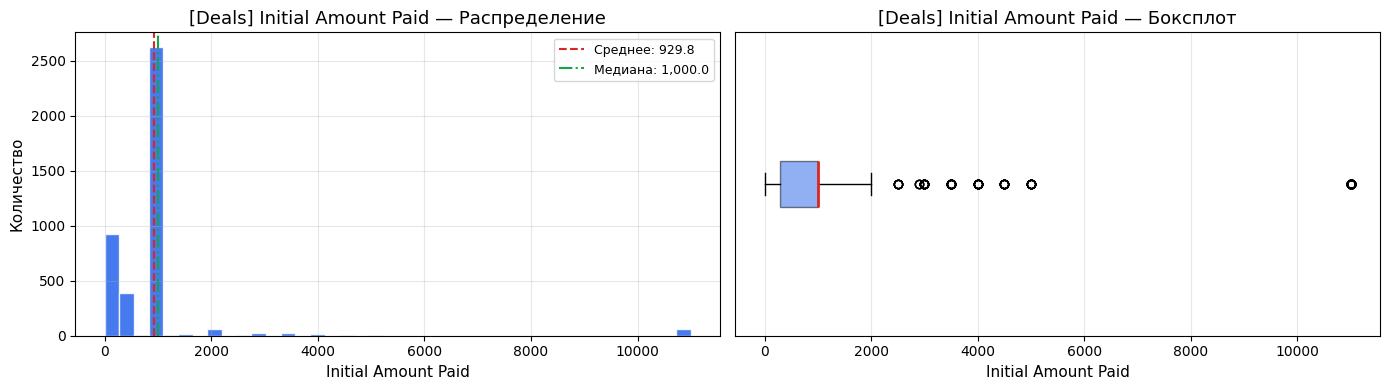

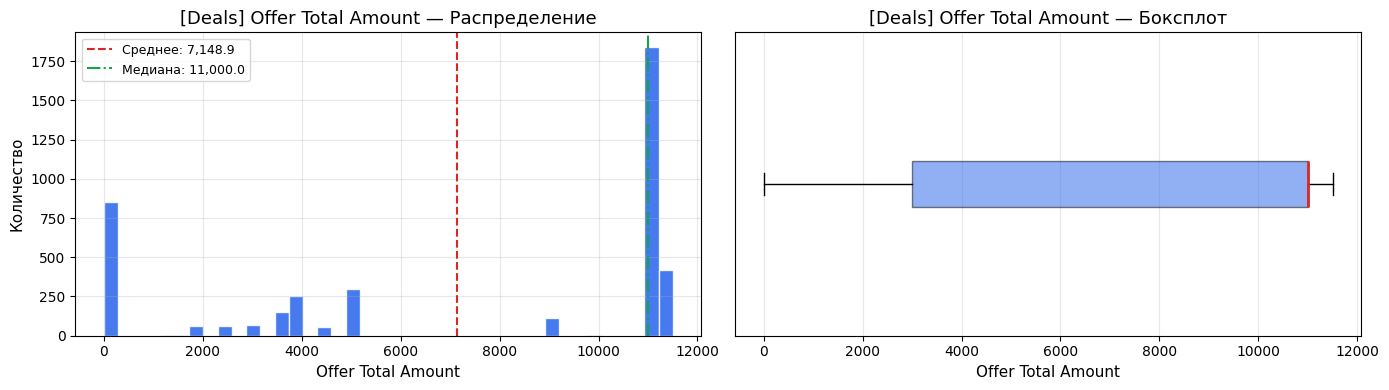

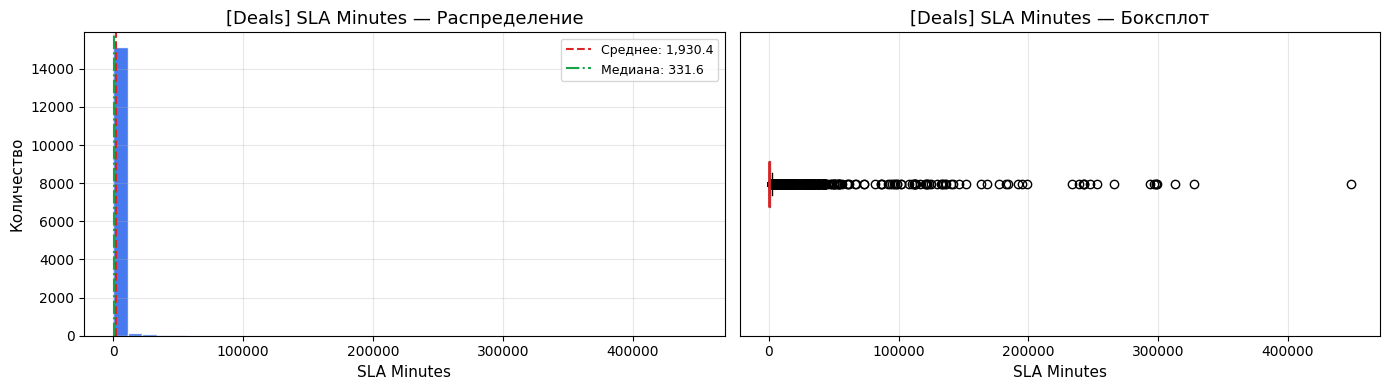

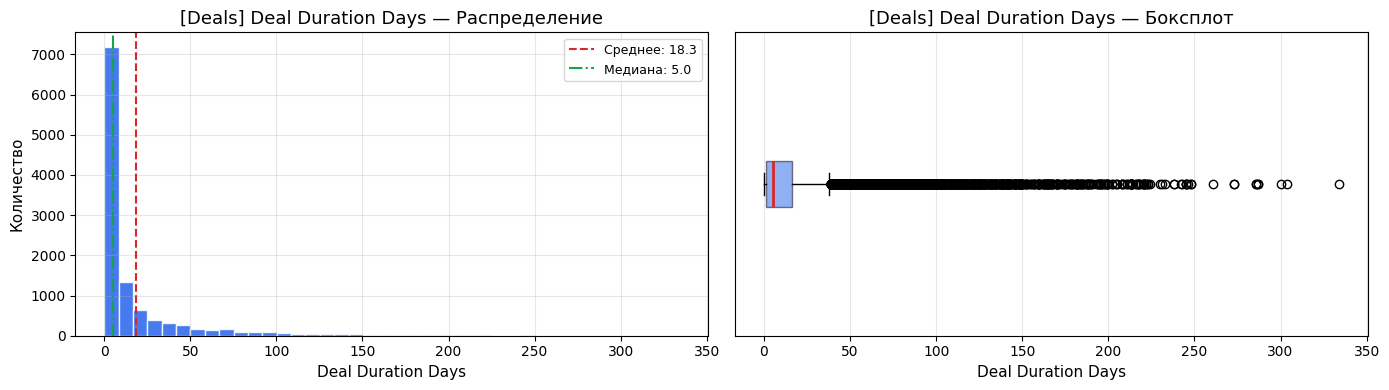

In [162]:
# Deal stages
plot_categorical_dual(df["Stage"], col_name="Stage",
                      df_name="Deals", top_n=15)

# Lead quality
plot_categorical_dual(df["Quality"], col_name="Quality",
                      df_name="Deals", top_n=5)

# German language proficiency
deutsch_cnt = df["Level of Deutsch"].value_counts(sort=False)
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(deutsch_cnt.index.astype(str), deutsch_cnt.values,
       color="#2563EB", edgecolor="white")
ax.set_title("Distribution of German Language Proficiency", fontsize=13)
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

# Numerical features
plot_numeric_report(
    df[["Initial Amount Paid", "Offer Total Amount",
        "SLA Minutes", "Deal Duration Days"]],
    df_name="Deals"
)

# 21. Data Cleaning Quality Validation

In [163]:
print("=" * 58)
print("  DATA QUALITY VALIDATION")
print("=" * 58)
print(f"  Duplicate Ids: {df.duplicated(subset=['Id']).sum()}")
print(f"  Closing Date < Created Time: "
      f"{((df['Closing Date'] < df['Created Time']) & df['Closing Date'].notna()).sum()}")
print(f"  Initial Amount > Offer Total Amount: "
      f"{((df['Initial Amount Paid'] > df['Offer Total Amount']).fillna(False)).sum()}")
print(f"  Negative SLA Minutes: {(df['SLA Minutes'] < 0).sum()}")
print(f"  Negative Deal Duration: {(df['Deal Duration Days'] < 0).sum()}")
print(f"  Paid Deals (Is Paid): {df['Is Paid'].sum():,}")
print(f"  Overall Conversion Rate: {df['Is Paid'].mean()*100:.2f}%")
print("=" * 58)

  КОНТРОЛЬНЫЕ ПРОВЕРКИ
  Дубликатов по Id: 0
  Closing Date < Created Time: 0
  Initial > Offer Total: 0
  Отрицательный SLA Minutes: 0
  Отрицательная Deal Duration: 0
  Оплаченных сделок (Is Paid): 858
  Общая конверсия: 3.97%


# 22. Saving the Cleaned Dataset

In [164]:
df.to_pickle(CLEAN_PATH)
print(f"Saved to: {CLEAN_PATH}")
print(f"Final dataset shape: {df.shape}")
df.info()

Сохранено: ../data/clean/deals_clean.pkl
Итоговый размер: (21593, 30)
<class 'pandas.DataFrame'>
RangeIndex: 21593 entries, 0 to 21592
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Id                   21593 non-null  string        
 1   Deal Owner Name      21593 non-null  category      
 2   Closing Date         11359 non-null  datetime64[us]
 3   Quality              21593 non-null  category      
 4   Stage                21593 non-null  category      
 5   Lost Reason          21593 non-null  category      
 6   Page                 21593 non-null  category      
 7   Campaign             21593 non-null  category      
 8   SLA                  15533 non-null  object        
 9   Content              21593 non-null  category      
 10  Term                 21593 non-null  category      
 11  Source               21593 non-null  category      
 12  Payment Type         21593 no